# 05. Putting All Four Methods Side by Side

One table, one plot: no-integration baseline, Harmony, scVI, scANVI. For the last three
I reuse the Leiden clusters already computed and saved in notebooks 02-04 rather than
retraining anything — no need to burn another 15 minutes per model just to read off a
number. The baseline is the one thing not computed yet: we looked at it on a UMAP back in
notebook 01, but never actually put a number on it.


In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

sc.settings.verbosity = 1
RESOLUTIONS = [0.3, 0.5, 0.7, 1.0, 1.3]

## 1. Baseline (no integration) — computing the metrics

The same thing as the baseline UMAP in notebook 01, but now with Leiden clustering and
ARI/NMI, not just a visual impression.

In [2]:
adata_baseline = sc.read("../data/processed/pancreas_prepared.h5ad")

sc.pp.highly_variable_genes(adata_baseline, n_top_genes=2000, batch_key="tech", subset=False)
adata_baseline = adata_baseline[:, adata_baseline.var["highly_variable"]].copy()
sc.pp.scale(adata_baseline, max_value=10)
sc.tl.pca(adata_baseline, n_comps=30)
sc.pp.neighbors(adata_baseline, use_rep="X_pca")

baseline_rows = []
for res in RESOLUTIONS:
    key = f"leiden_r{res}"
    sc.tl.leiden(adata_baseline, resolution=res, flavor="igraph", n_iterations=2, directed=False, key_added=key)
    ari = adjusted_rand_score(adata_baseline.obs["celltype"], adata_baseline.obs[key])
    nmi = normalized_mutual_info_score(adata_baseline.obs["celltype"], adata_baseline.obs[key])
    baseline_rows.append({"method": "baseline (no integration)", "resolution": res, "ARI": ari, "NMI": nmi,
                           "n_clusters": adata_baseline.obs[key].nunique()})

pd.DataFrame(baseline_rows)

,method,resolution,ARI,NMI,n_clusters
0,baseline (no integration),0.3,0.427919,0.707524,19
1,baseline (no integration),0.5,0.321837,0.675942,27
2,baseline (no integration),0.7,0.318235,0.673485,29
3,baseline (no integration),1.0,0.291627,0.671243,32
4,baseline (no integration),1.3,0.288296,0.668877,34


## 2. Harmony / scVI / scANVI — recomputing ARI/NMI from the already-saved Leiden clusters

The files `pancreas_harmony.h5ad`, `pancreas_scvi.h5ad`, `pancreas_scanvi.h5ad` already
contain `leiden_r0.3`, `leiden_r0.5`, etc. columns from their respective notebooks — we
just read them and compute metrics, without retraining any models.

In [3]:
method_files = {
    "Harmony": "../data/processed/pancreas_harmony.h5ad",
    "scVI": "../data/processed/pancreas_scvi.h5ad",
    "scANVI": "../data/processed/pancreas_scanvi.h5ad",
}

all_rows = list(baseline_rows)

for method_name, path in method_files.items():
    ad = sc.read(path)
    for res in RESOLUTIONS:
        key = f"leiden_r{res}"
        if key not in ad.obs.columns:
            print(f"Skipping: {key} not found in {path}")
            continue
        ari = adjusted_rand_score(ad.obs["celltype"], ad.obs[key])
        nmi = normalized_mutual_info_score(ad.obs["celltype"], ad.obs[key])
        all_rows.append({"method": method_name, "resolution": res, "ARI": ari, "NMI": nmi,
                          "n_clusters": ad.obs[key].nunique()})

full_sweep_df = pd.DataFrame(all_rows)
full_sweep_df

,method,resolution,ARI,NMI,n_clusters
0,baseline (no integration),0.3,0.427919,0.707524,19
1,baseline (no integration),0.5,0.321837,0.675942,27
2,baseline (no integration),0.7,0.318235,0.673485,29
3,baseline (no integration),1.0,0.291627,0.671243,32
4,baseline (no integration),1.3,0.288296,0.668877,34
5,Harmony,0.3,0.914267,0.888037,12
6,Harmony,0.5,0.885303,0.867960,16
7,Harmony,0.7,0.775823,0.832568,17
8,Harmony,1.0,0.579977,0.775674,20
9,Harmony,1.3,0.465018,0.738594,24


## 3. Plot: ARI across all methods and resolutions at once

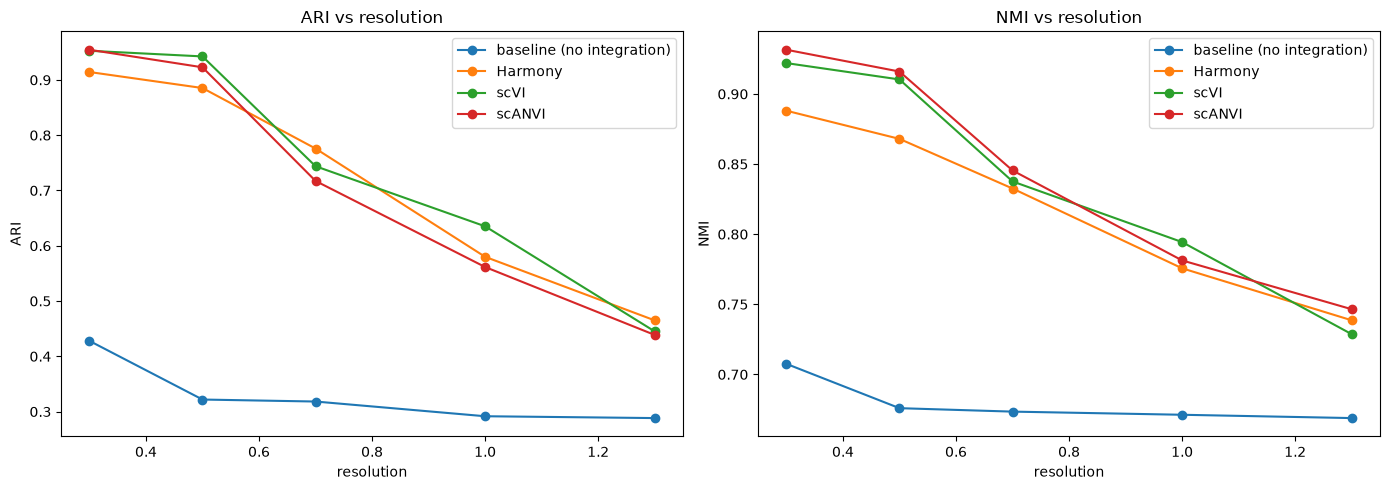

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for method_name in full_sweep_df["method"].unique():
    subset = full_sweep_df[full_sweep_df["method"] == method_name].sort_values("resolution")
    axes[0].plot(subset["resolution"], subset["ARI"], marker="o", label=method_name)
    axes[1].plot(subset["resolution"], subset["NMI"], marker="o", label=method_name)

axes[0].set_xlabel("resolution"); axes[0].set_ylabel("ARI"); axes[0].set_title("ARI vs resolution")
axes[1].set_xlabel("resolution"); axes[1].set_ylabel("NMI"); axes[1].set_title("NMI vs resolution")
axes[0].legend(); axes[1].legend()
plt.tight_layout()
plt.savefig("../results/figures/05_all_methods_sweep.png", dpi=150)
plt.show()

**What matters here**: if the baseline line sits noticeably below the other three
across the whole resolution range — that's the quantitative confirmation of what we saw
on the UMAP in notebook 01: without batch-effect correction, Leiden clusters mostly by
technology rather than biology, and this doesn't depend on the choice of resolution.

## 4. Final summary table — best result per method

In [5]:
best_per_method = (
    full_sweep_df.loc[full_sweep_df.groupby("method")["ARI"].idxmax()]
    .sort_values("ARI", ascending=False)
    .reset_index(drop=True)
)
best_per_method

,method,resolution,ARI,NMI,n_clusters
0,scANVI,0.3,0.954550,0.931522,13
1,scVI,0.3,0.952699,0.921997,11
2,Harmony,0.3,0.914267,0.888037,12
3,baseline (no integration),0.3,0.427919,0.707524,19


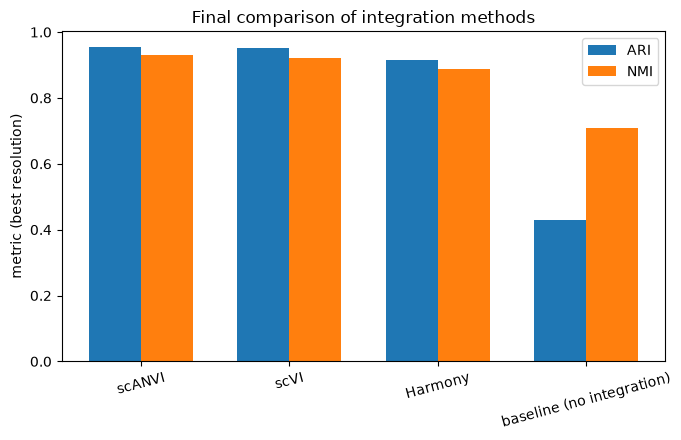

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(best_per_method))
width = 0.35
ax.bar(x - width/2, best_per_method["ARI"], width, label="ARI")
ax.bar(x + width/2, best_per_method["NMI"], width, label="NMI")
ax.set_xticks(x)
ax.set_xticklabels(best_per_method["method"], rotation=15)
ax.set_ylabel("metric (best resolution)")
ax.set_title("Final comparison of integration methods")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/05_final_comparison.png", dpi=150)
plt.show()

## 4b. Three honest views on the held-out cells

scANVI saw the labels of ~85 % of the cells, so its all-cell ARI/NMI above is not
comparable with Harmony or scVI. The obvious fix — score only the 2394 held-out
`smartseq2` cells — turns out to be uninformative for a different reason. This section
reports three views and says what each can and cannot show: (1) Leiden ARI/NMI
restricted to held-out cells, (2) cross-batch kNN label transfer from all labelled
reference cells to the held-out cells, per latent space, (3) batch mixing vs cell-type
purity of each cell's 50 nearest neighbours — the two axes integration actually trades
off.


                   method  ARI_all  NMI_all  resolution  ARI_heldout  NMI_heldout  kNN_transfer_acc  kNN_transfer_macroF1  batch_mixing_all  batch_mixing_heldout  celltype_purity_all  celltype_purity_heldout
                   scANVI    0.955    0.932         0.3        0.953        0.942             0.982                 0.963             0.677                 0.772                0.979                    0.972
                     scVI    0.953    0.922         0.3        0.966        0.944             0.980                 0.968             0.649                 0.770                0.959                    0.959
                  Harmony    0.914    0.888         0.3        0.950        0.933             0.980                 0.902             0.793                 0.820                0.959                    0.969
baseline (no integration)    0.428    0.708         0.3        0.918        0.911             0.981                 0.938             0.203                 0.118       

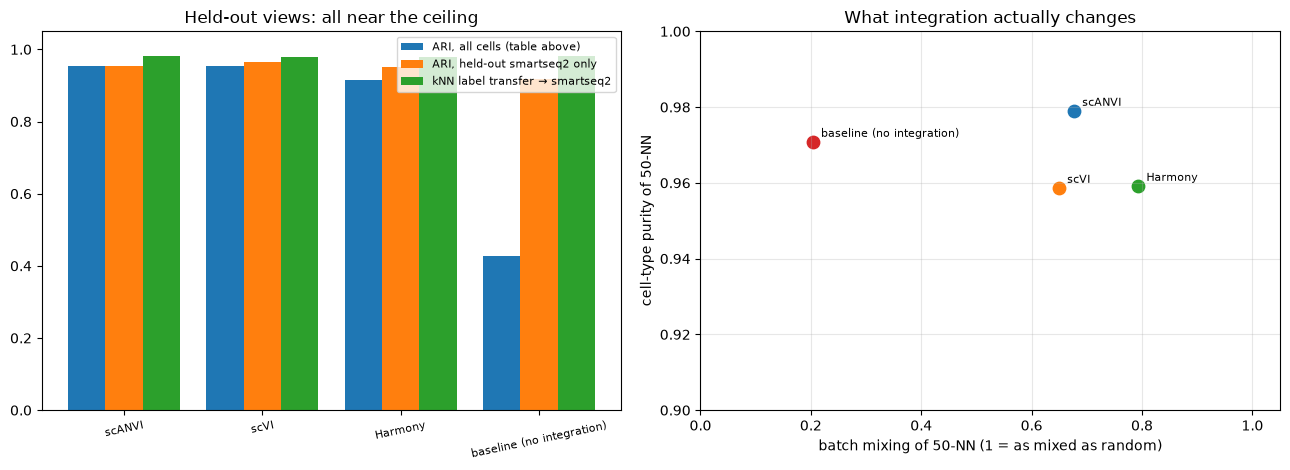

In [7]:
# The table above has a flaw: scANVI was trained with the labels of ~85 % of the cells, so
# its all-cell ARI/NMI is not comparable with Harmony or scVI. The natural fix — score only
# the 2394 held-out smartseq2 cells — turns out to be uninformative for a different reason,
# so this section reports three views and says what each one can and cannot show.
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import accuracy_score, f1_score

HOLDOUT_TECH = "smartseq2"
latents = {"baseline (no integration)": (adata_baseline, "X_pca")}
for m, p in method_files.items():
    ad_m = sc.read(p)
    latents[m] = (ad_m, {"Harmony": "X_pca_harmony", "scVI": "X_scVI", "scANVI": "X_scANVI"}[m])

K = 50
rows = []
for method_name, (ad_m, rep) in latents.items():
    obs, Z = ad_m.obs, ad_m.obsm[rep]
    tech = obs["tech"].astype(str).values
    ct = obs["celltype"].astype(str).values
    ho = tech == HOLDOUT_TECH
    res = float(best_per_method.loc[best_per_method["method"] == method_name, "resolution"].iloc[0])
    cl = obs[f"leiden_r{res}"]

    # (1) Leiden ARI/NMI restricted to the held-out cells
    ari_ho = adjusted_rand_score(ct[ho], cl[ho])
    nmi_ho = normalized_mutual_info_score(ct[ho], cl[ho])

    # (2) cross-batch kNN label transfer: reference = all labelled non-smartseq2 cells
    knn = KNeighborsClassifier(n_neighbors=15, weights="distance").fit(Z[~ho], ct[~ho])
    pred = knn.predict(Z[ho])
    acc = accuracy_score(ct[ho], pred)
    f1 = f1_score(ct[ho], pred, average="macro", labels=sorted(set(ct[ho])))  # same label set as in 07

    # (3) batch mixing vs cell-type purity of the K nearest neighbours (all cells)
    idx = NearestNeighbors(n_neighbors=K + 1).fit(Z).kneighbors(Z, return_distance=False)[:, 1:]
    other_tech = (tech[idx] != tech[:, None]).mean(1)
    expected = 1 - pd.Series(tech).value_counts(normalize=True)[tech].values
    mixing = np.minimum(other_tech / expected, 1)           # 1 = neighbours as mixed as random
    purity = (ct[idx] == ct[:, None]).mean(1)               # 1 = neighbours all same cell type

    rows.append({"method": method_name, "resolution": res,
                 "ARI_heldout": ari_ho, "NMI_heldout": nmi_ho,
                 "kNN_transfer_acc": acc, "kNN_transfer_macroF1": f1,
                 "batch_mixing_all": mixing.mean(), "batch_mixing_heldout": mixing[ho].mean(),
                 "celltype_purity_all": purity.mean(), "celltype_purity_heldout": purity[ho].mean()})

heldout = (best_per_method[["method", "ARI", "NMI"]].rename(columns={"ARI": "ARI_all", "NMI": "NMI_all"})
           .merge(pd.DataFrame(rows), on="method"))
heldout.to_csv("../results/heldout_metrics.csv", index=False)
print(heldout.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
x = np.arange(len(heldout)); w = 0.27
axes[0].bar(x - w, heldout["ARI_all"], w, label="ARI, all cells (table above)")
axes[0].bar(x, heldout["ARI_heldout"], w, label="ARI, held-out smartseq2 only")
axes[0].bar(x + w, heldout["kNN_transfer_acc"], w, label="kNN label transfer → smartseq2")
axes[0].set_xticks(x); axes[0].set_xticklabels(heldout["method"], rotation=12, fontsize=8)
axes[0].set_ylim(0, 1.05); axes[0].legend(fontsize=8); axes[0].set_title("Held-out views: all near the ceiling")
for _, r in heldout.iterrows():
    axes[1].scatter(r["batch_mixing_all"], r["celltype_purity_all"], s=80)
    axes[1].annotate(r["method"], (r["batch_mixing_all"], r["celltype_purity_all"]),
                     textcoords="offset points", xytext=(6, 4), fontsize=8)
axes[1].set_xlabel(f"batch mixing of {K}-NN (1 = as mixed as random)")
axes[1].set_ylabel(f"cell-type purity of {K}-NN")
axes[1].set_xlim(0, 1.05); axes[1].set_ylim(0.90, 1.0); axes[1].set_title("What integration actually changes")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../results/figures/05_heldout_views.png", dpi=150)
plt.show()


## 5. Saving the summary table

In [8]:
full_sweep_df.to_csv("../results/all_methods_metrics.csv", index=False)
best_per_method.to_csv("../results/best_per_method.csv", index=False)
print("Saved to results/")

Saved to results/


## Conclusions

| Method | ARI all cells | ARI held-out | kNN transfer acc. | kNN transfer macro-F1 | batch mixing | cell-type purity |
|---|---|---|---|---|---|---|
| scANVI | 0.955 | 0.953 | 0.982 | 0.963 | 0.677 | 0.979 |
| scVI | 0.953 | 0.966 | 0.980 | 0.968 | 0.649 | 0.959 |
| Harmony | 0.914 | 0.950 | 0.980 | 0.902 | 0.793 | 0.959 |
| baseline (no integration) | 0.428 | 0.918 | 0.981 | 0.938 | 0.203 | 0.971 |

*(from `results/heldout_metrics.csv`; single runs, seed 0 for scVI/scANVI)*

The all-cell ARI ranking (scANVI > scVI > Harmony ≫ baseline) survives, but it answers a
narrower question than it looks. On the held-out technology every latent space —
including uncorrected PCA — clusters cleanly (ARI 0.92–0.97) and transfers labels at
≈ 98 %: within one technology there is no batch effect to remove, and across technologies
the batch shift is smaller than the distance between cell types, so nearest neighbours are
the right type even before correction. What integration changes is batch *mixing*
(0.20 → 0.65–0.79), and there Harmony leads, not scANVI. scANVI's purity edge is what
supervision buys, not what integration buys.

Two details worth a sentence each. A kNN classifier on scANVI's own latent space reaches
macro-F1 0.963, above scANVI's built-in classification head (0.930 in 04, 0.94 ± 0.01 over
seeds): the latent space is good, the head is the weaker part. And on held-out ARI the
single runs here put scVI above scANVI (0.966 vs 0.953), while the five-seed sweep in 07
puts scANVI slightly ahead (0.952 ± 0.007 vs 0.943 ± 0.005) — one run per method cannot
order two methods that are 0.01 apart.

The baseline's NMI (0.708) sitting well above its ARI (0.428) is worth keeping: even
uncorrected data carries real information about cell identity, it's just scattered across
many small, technology-specific clusters — NMI tolerates that fragmentation better than ARI.

Next: `07_seed_stability.ipynb` (five seeds) and `08_error_anatomy.ipynb` (what the
label-transfer errors are made of). `06_error_analysis.md` is the first-pass narrative,
kept for the record.